# Learning to fly with OME-Arrow

This notebook provides a quick demonstration of what you can do with OME Arrow.

In [1]:
# we import a single class, OMEArrow
# which handles all data I/O and manipulation
from ome_arrow import OMEArrow

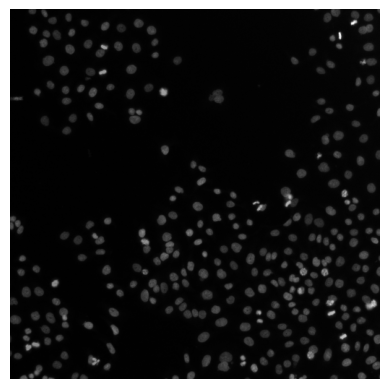

In [2]:
# read a TIFF file and convert it to OME-Arrow
oa_image = OMEArrow(
    data="../../../tests/data/examplehuman/AS_09125_050116030001_D03f00d0.tif"
)
# by default, the image and metadata are shown
oa_image

In [3]:
# we can also get a summary of the OME-Arrow object
oa_image.info()

{'shape': (1, 1, 1, 512, 512),
 'type': '2D image',
 'channels': 1,
 'is_multichannel': False,
 'summary': '2D image, single-channel - shape (T=1, C=1, Z=1, Y=512, X=512)'}

In [4]:
# we can export the data into a number
# of different formats, e.g. numpy
oa_image.export(how="numpy")

array([[[[[ 8,  8,  8, ..., 63, 78, 75],
          [ 8,  8,  7, ..., 67, 71, 71],
          [ 9,  8,  8, ..., 53, 64, 66],
          ...,
          [ 8,  9,  8, ..., 17, 24, 59],
          [ 8,  8,  8, ..., 17, 22, 55],
          [ 8,  8,  8, ..., 16, 18, 38]]]]],
      shape=(1, 1, 1, 512, 512), dtype=uint16)

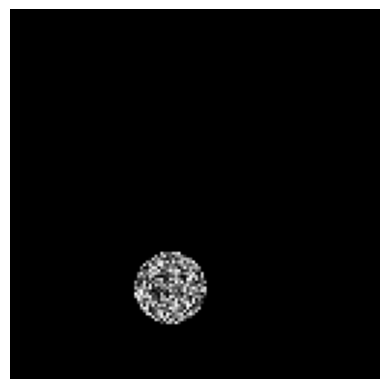

In [5]:
# We can also read in TIFF stacks following OME bfconvert API conventions
stack = OMEArrow(
    data="../../../tests/data/nviz-artificial-4d-dataset/E99_C<111,222>_ZS<000-021>.tif",
    # this is an optional for which
    # timepoint, channel, and z-slice to show by default
    tcz=(0, 0, 20),
)
stack

Widget(value='<iframe src="http://localhost:61917/index.html?ui=P_0x14dcc3f10_0&reconnect=auto" class="pyvista…


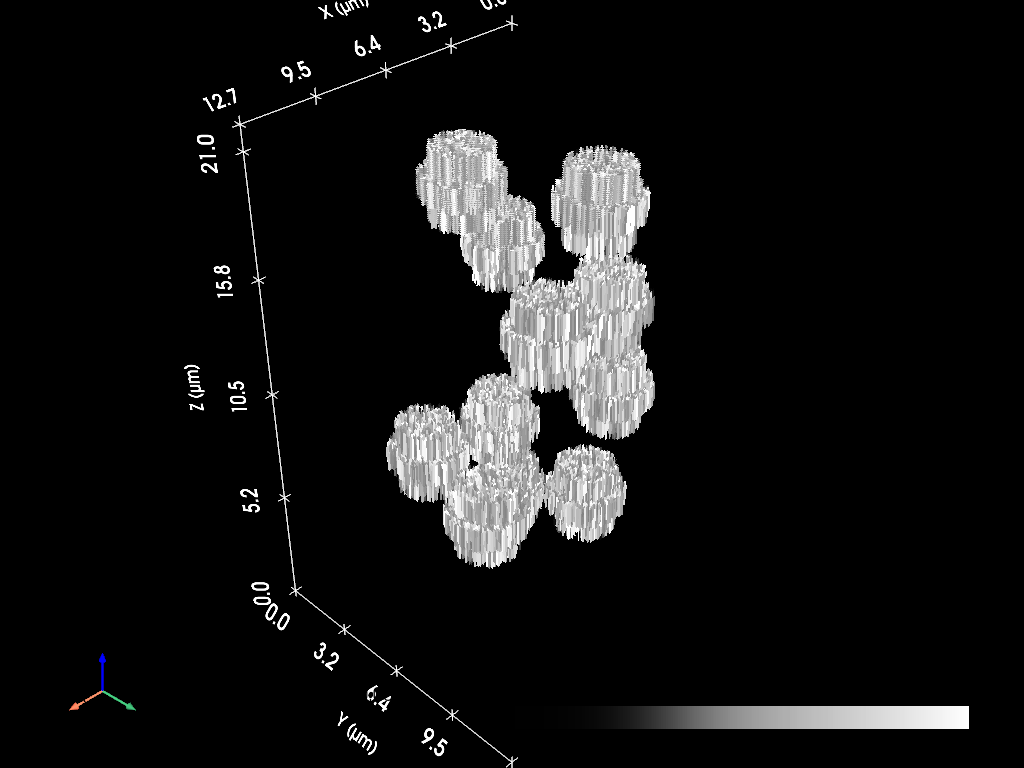

In [6]:
# we can visualize the stack using pyvista for 3D rendering
# note: we use manually specified scaling values here
# and can also default to what the image metadata provides
# with `scaling_values=None` (the default).
stack.view(how="pyvista", scaling_values=(1, 0.1, 0.1))

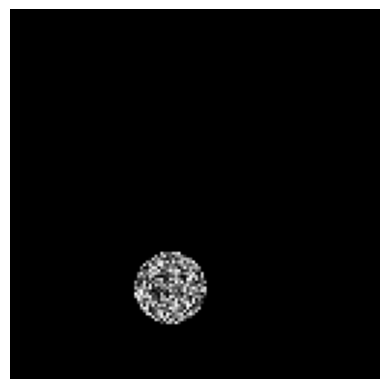

In [7]:
# here we demonstrate that the data can be exported again
# into numpy format and re-imported
# into a new OME-Arrow object (from numpy data).
stack_np = stack.export(how="numpy")
OMEArrow(data=stack_np, tcz=(0, 0, 20))

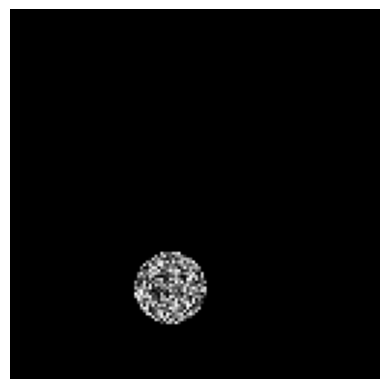

In [8]:
# here we demonstrate that the data can be exported again
# into OME-TIFF format and re-imported
# into a new OME-Arrow object (from OME-TIFF data).
stack.export(how="ome-tiff", out="example.ome.tiff")
OMEArrow(data="example.ome.tiff", tcz=(0, 0, 20))

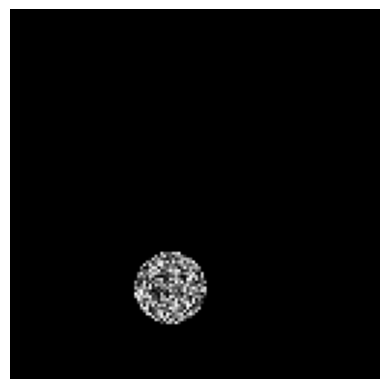

In [9]:
# here we demonstrate that the data can be exported again
# into OME-ZARR format and re-imported
# into a new OME-Arrow object (from OME-ZARR data).
stack.export(how="ome-zarr", out="example.ome.zarr")
OMEArrow(data="example.ome.zarr", tcz=(0, 0, 20))

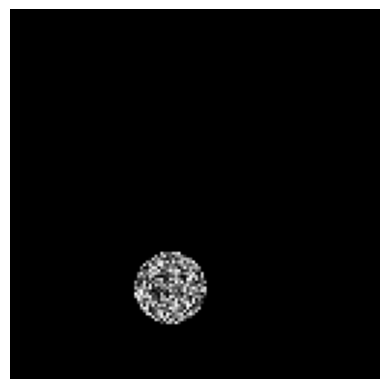

In [10]:
# here we demonstrate that the data can be exported again
# into OME-Parquet format and re-imported
# into a new OME-Arrow object (from OME-Parquet data).
stack.export(how="ome-parquet", out="example.ome.parquet")
OMEArrow(data="example.ome.parquet", tcz=(0, 0, 20))

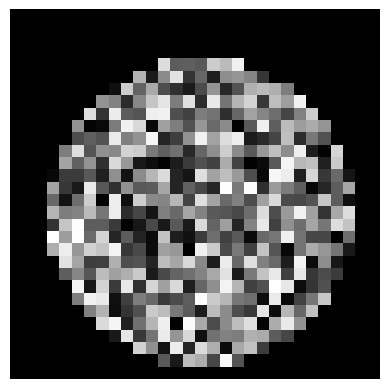

In [11]:
# we can also slice the data to get a smaller region of interest
stack.slice(
    x_min=40,
    y_min=80,
    x_max=70,
    y_max=110,
    t_indices=[0],
    c_indices=[0],
    z_indices=[20],
)

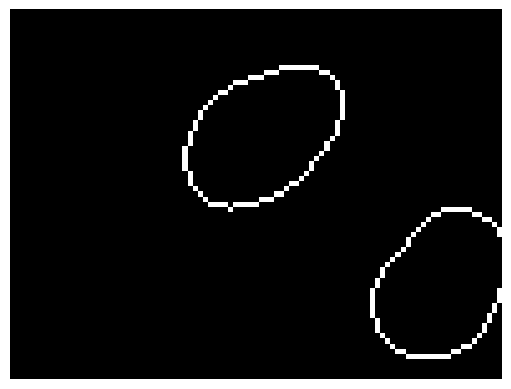

In [12]:
# read from a multi-image OME Parquet file as OME-Arrow
# note: the Parquet file was created using the CytoDataFrame project
# which helps convert CellProfiler and Image data into OME-Parquet format.
# see here for more details:
# https://github.com/cytomining/CytoDataFrame/blob/main/docs/src/examples/cytodataframe_at_a_glance.ipynb
oa_image = OMEArrow(
    data="../../../tests/data/JUMP-BR00117006/BR00117006.ome.parquet",
    # we can specify which column and row to read
    # (or rely on OMEArrow to find a suitable default)
    column_name="Image_FileName_OrigDNA_OMEArrow_LABL",
    row_index=2,
)
# by default, the image and metadata are shown
oa_image

Widget(value='<iframe src="http://localhost:61917/index.html?ui=P_0x37dba4550_1&reconnect=auto" class="pyvista…


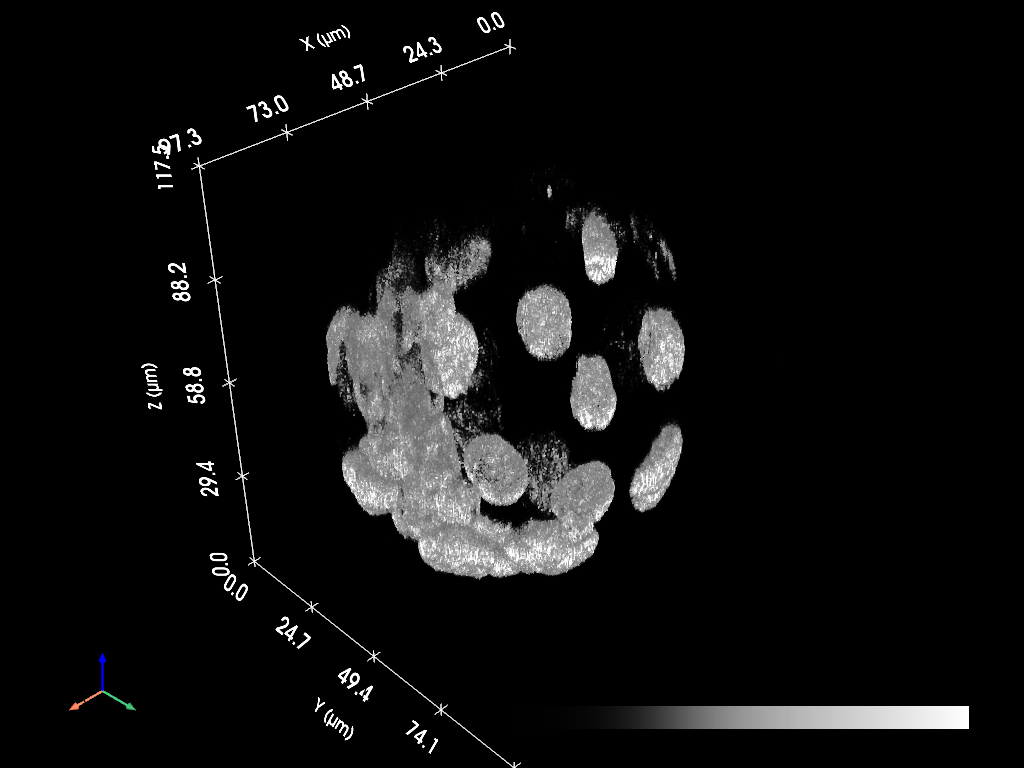

In [13]:
# read a 3d zarr image from IDR
oa_image = OMEArrow(data="../../../tests/data/idr0062A/6001240_labels.zarr")
# show the image using pyvista
oa_image.view(how="pyvista")

## DLPack tensor export (advanced)
This is optional and requires torch: `pip install "ome-arrow[dlpack-torch]"`

In [ ]:
# examples of exporting OME-Arrow data into DLPack format for zero-copy
import jax.numpy as jnp
import torch

oa = OMEArrow("example.ome.parquet")

In [15]:
%%time
# DLPack Arrow mode: zero-copy 1D values buffer + reshape
view = oa.tensor_view(t=0, z=0, c=0)
cap = view.to_dlpack(mode="arrow")
flat = torch.utils.dlpack.from_dlpack(cap)
tensor = flat.reshape(view.shape)
tensor.shape

CPU times: user 139 ms, sys: 2.58 ms, total: 141 ms
Wall time: 144 ms


torch.Size([1, 128, 128])

In [ ]:
%%time
# DLPack NumPy mode: shaped tensor directly (still zero-copy when possible)
# Layout quick reference:
# - `C` = channels
# - `H` = image height (Y axis)
# - `W` = image width (X axis)
view_chw = oa.tensor_view(t=0, z=0, layout="CHW")
cap_chw = view_chw.to_dlpack(mode="numpy", contiguous=True)
tensor_chw = torch.utils.dlpack.from_dlpack(cap_chw)
tensor_chw.shape

CPU times: user 142 ms, sys: 2.31 ms, total: 144 ms
Wall time: 143 ms


torch.Size([2, 128, 128])

In [17]:
%%time
# DLPack Arrow mode: zero-copy 1D values buffer + reshape
view = oa.tensor_view(t=0, z=0, c=0)
caps = view.to_dlpack(mode="arrow")
flat = jnp.from_dlpack(caps)
arr = flat.reshape(view.shape)
arr.shape

CPU times: user 162 ms, sys: 23.7 ms, total: 186 ms
Wall time: 253 ms


(1, 128, 128)